# Object Counting using Digital Signal Processing: Philippine Coins
An image is a 2-D discrete signal. Each step below is a signal-processing operation:

1. **Low-pass filtering** (Gaussian) to suppress noise
2. **Color-distance thresholding** (Otsu) to separate coins from the background
3. **Morphological filtering** to clean the binary signal
4. **Distance transform + watershed** to split touching coins
5. **Feature extraction**: size, plus the color of the outer ring and of the center of each coin
6. **Classification** by appearance (silver / brass / two-tone) and size

The coin value is decided mainly by **color and appearance**, and size is only used where color cannot decide.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy import ndimage as ndi
from skimage.measure import label, regionprops
from skimage.morphology import disk, opening
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

IMAGE_PATH = 'Images/coins.png'   # change this to your image

img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

# Settings that scale with the picture size, so any resolution works
SIGMA      = 0.002 * max(h, w)               # Gaussian blur strength
OPEN_R     = max(3, int(0.004 * max(h, w)))  # radius of the morphological opening
MIN_AREA   = 0.001 * h * w                   # ignore blobs smaller than this
print("Image size:", (h, w))

Image size: (3024, 4032)


## 1. Low-pass filtering
A Gaussian kernel averages each pixel with its neighbors, which removes high-frequency noise. The 2-D FFT shows the effect: the filtered spectrum has less energy away from the center.

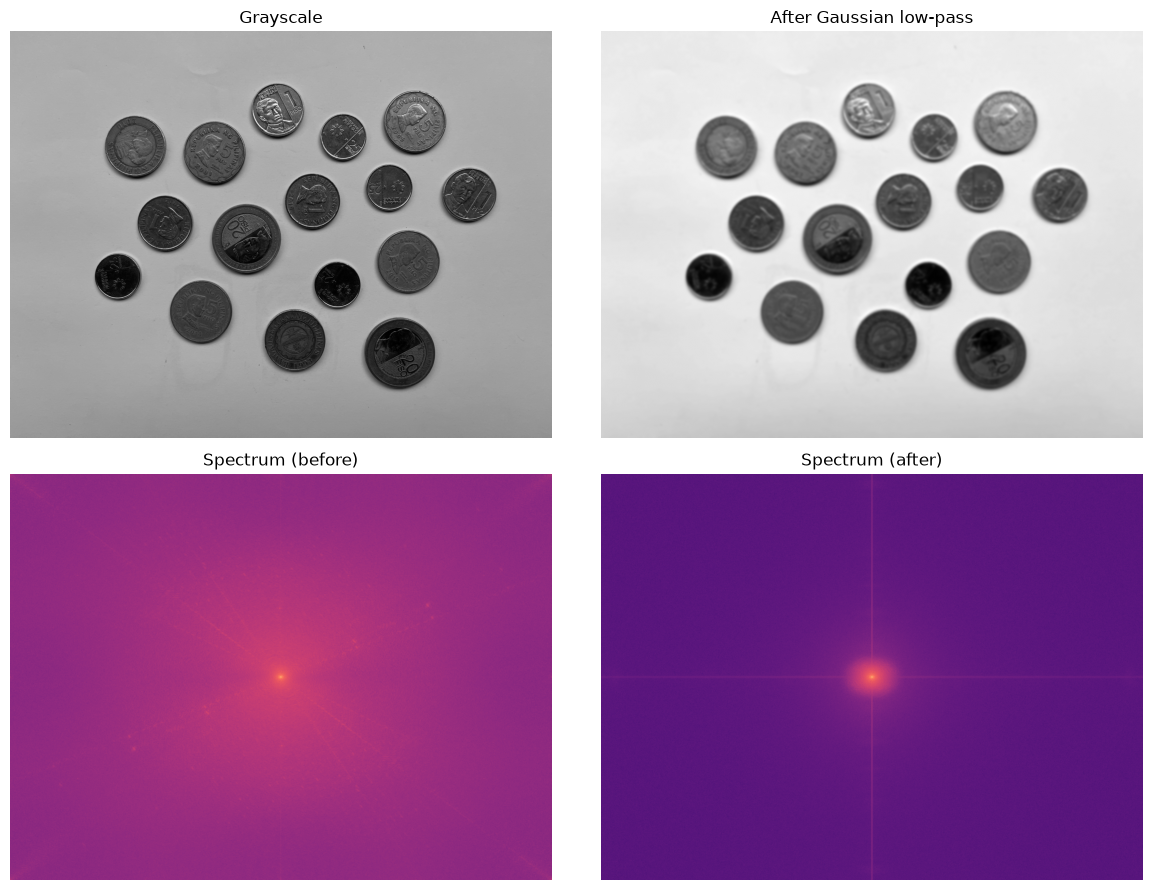

In [2]:
# True L*a*b* color (L: 0-100, a and b: about -128..127). Gold looks yellow, so b* is large for gold.
lab = cv2.cvtColor(img.astype(np.float32) / 255.0, cv2.COLOR_BGR2LAB)
lab_blur = cv2.GaussianBlur(lab, (0, 0), SIGMA)
gray_blur = cv2.GaussianBlur(gray, (0, 0), SIGMA)

def spectrum(im):
    return np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(im.astype(float)))))

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs[0, 0].imshow(gray, cmap='gray');            axs[0, 0].set_title("Grayscale")
axs[0, 1].imshow(gray_blur, cmap='gray');       axs[0, 1].set_title("After Gaussian low-pass")
axs[1, 0].imshow(spectrum(gray), cmap='magma'); axs[1, 0].set_title("Spectrum (before)")
axs[1, 1].imshow(spectrum(gray_blur), cmap='magma'); axs[1, 1].set_title("Spectrum (after)")
for a in axs.flat: a.axis("off")
plt.tight_layout(); plt.show()

## 2. Separating coins from the background
The background color is taken from the image border. Every pixel is then given a number: its color distance from that background. Brightness counts less than hue, so the dark shadows next to the coins are not mistaken for coin. Otsu's method picks the threshold automatically.

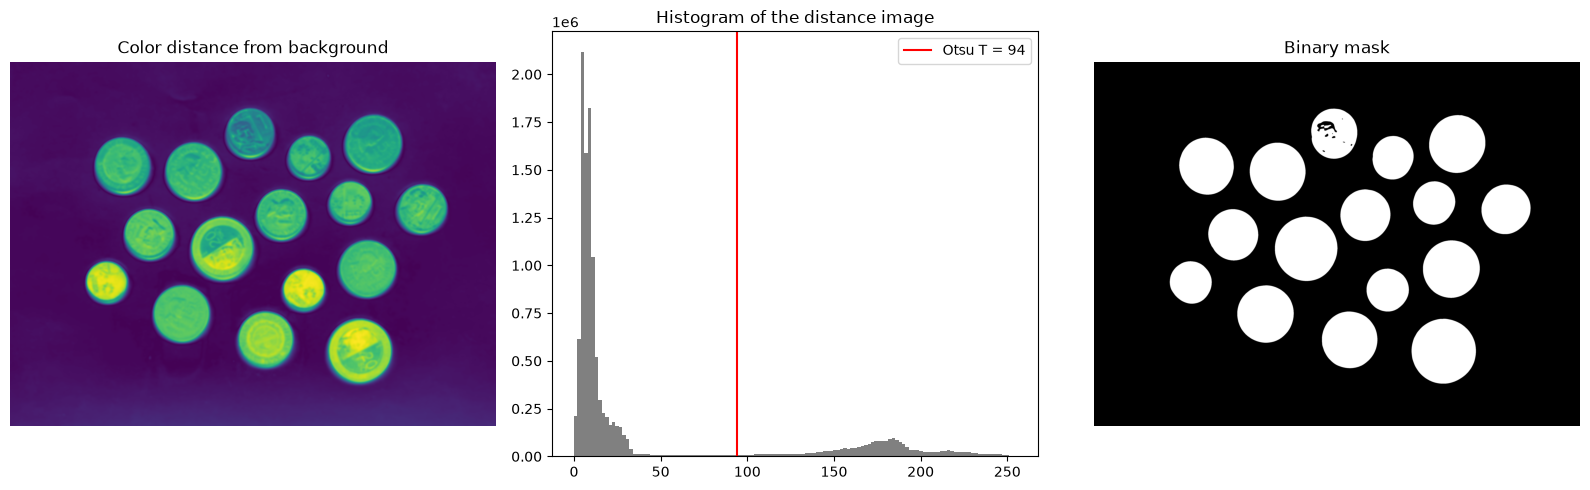

In [3]:
border = np.concatenate([lab_blur[0], lab_blur[-1], lab_blur[:, 0], lab_blur[:, -1]])
bg_color = np.median(border, axis=0)

L_WEIGHT = 1.2                                   # < 1 would ignore brightness more
diff = lab_blur - bg_color
diff[..., 0] *= L_WEIGHT
dist_bg = np.linalg.norm(diff, axis=2)

dist_u8 = np.clip(dist_bg / dist_bg.max() * 255, 0, 255).astype(np.uint8)
T, _ = cv2.threshold(dist_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
mask = dist_u8 > T

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(dist_bg, cmap='viridis'); axs[0].set_title("Color distance from background"); axs[0].axis("off")
axs[1].hist(dist_u8.ravel(), bins=128, color='gray'); axs[1].axvline(T, color='r', label=f"Otsu T = {T:.0f}")
axs[1].set_title("Histogram of the distance image"); axs[1].legend()
axs[2].imshow(mask, cmap='gray'); axs[2].set_title("Binary mask"); axs[2].axis("off")
plt.tight_layout(); plt.show()

## 3. Morphological filtering
Fill holes inside the coins, then use an opening (erosion followed by dilation) to remove thin lines and specks.

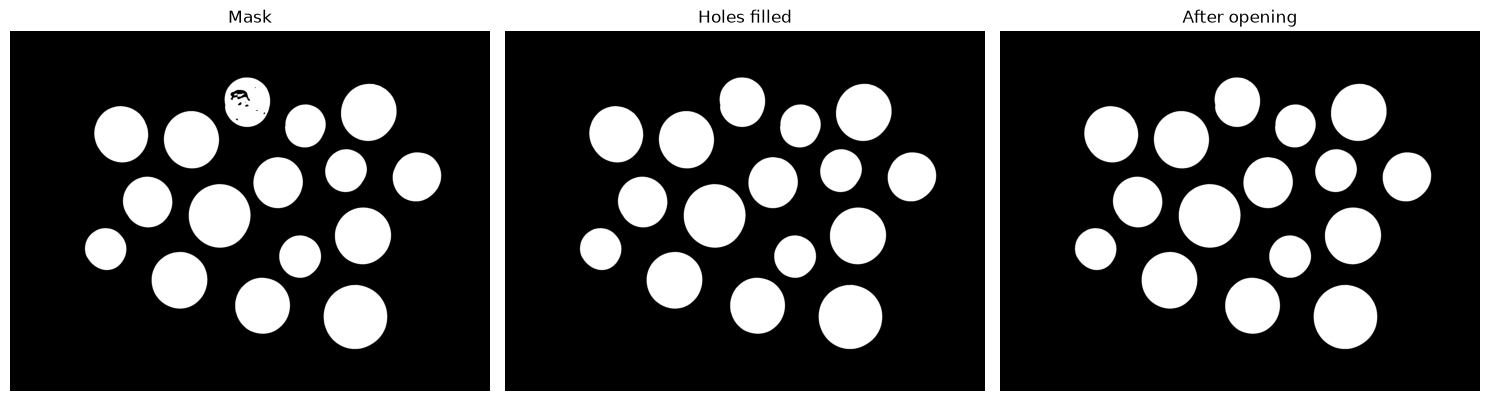

In [4]:
filled = ndi.binary_fill_holes(mask)
clean = opening(filled, disk(OPEN_R))

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for a, im, ti in zip(axs, [mask, filled, clean], ["Mask", "Holes filled", "After opening"]):
    a.imshow(im, cmap='gray'); a.set_title(ti); a.axis("off")
plt.tight_layout(); plt.show()

## 4. Separating touching coins
The distance transform gives each pixel its distance to the nearest background pixel, so coin centers become peaks. Watershed then splits touching coins along the valleys between peaks.

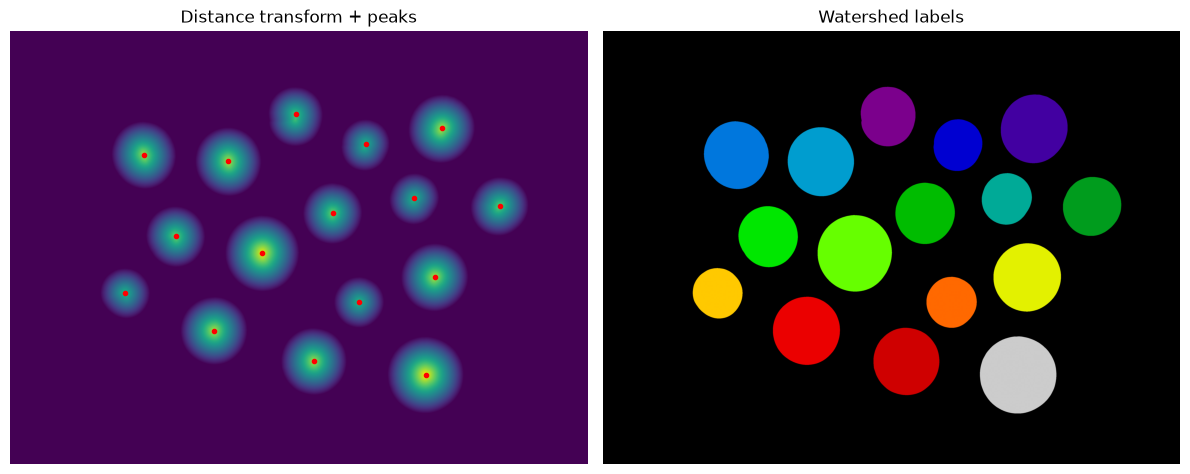

In [5]:
dist = ndi.distance_transform_edt(clean)
peaks = peak_local_max(dist, min_distance=max(20, int(0.25 * dist.max())),
                       threshold_abs=0.4 * dist.max(), labels=label(clean))

markers = np.zeros_like(dist, dtype=int)
for i, (r, c) in enumerate(peaks, start=1):
    markers[r, c] = i
labels = watershed(-dist, markers, mask=clean)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(dist, cmap='viridis'); axs[0].plot(peaks[:, 1], peaks[:, 0], 'r.')
axs[0].set_title("Distance transform + peaks"); axs[0].axis("off")
axs[1].imshow(labels, cmap='nipy_spectral'); axs[1].set_title("Watershed labels"); axs[1].axis("off")
plt.tight_layout(); plt.show()

## 5. Measuring each coin
For every coin the code measures:

- **Diameter**: the largest circle that fits inside the coin (from the distance transform). Shadows stick out of the coin but do not change this circle, so it is more accurate than the blob area.
- **Center color**: the median b* inside the middle of the coin.
- **Ring color**: the median b* in a band along the outer edge.

b* is the yellow-blue axis of L*a*b* color. **Silver coins have a low b\*, gold/brass coins have a high b\*.**

In [6]:
yy, xx = np.mgrid[:h, :w]
coins = []
for r in regionprops(labels):
    if r.area < MIN_AREA:
        continue
    inside = labels == r.label
    d_here = np.where(inside, dist, 0)
    R = d_here.max()                                   # radius of the biggest inscribed circle
    cy, cx = np.unravel_index(d_here.argmax(), d_here.shape)
    rr = np.hypot(yy - cy, xx - cx)

    center_px = inside & (rr < 0.45 * R)
    ring_px   = inside & (rr > 0.82 * R) & (rr < 0.97 * R)

    coins.append({
        "cx": cx, "cy": cy, "d_px": 2 * R,
        "b_center": float(np.median(lab[center_px][:, 2])),
        "b_ring":   float(np.median(lab[ring_px][:, 2])),
    })

coins.sort(key=lambda c: (c["cy"] // (0.18 * h), c["cx"]))   # roughly top-to-bottom, left-to-right
print(f"Coins found: {len(coins)}")

Coins found: 16


## 6. Identifying the coin from its appearance
**Rules (in order):**

| Appearance | Coin |
|---|---|
| Gold ring + silver center | **20 peso** |
| Silver ring + gold center | **10 peso** |
| Gold all over (brass) | **5 peso** (or 25 centavos if it is small) |
| Silver all over | **25 centavos** or **1 peso**, decided by size |

"Gold" vs "silver" is decided automatically: all measured b* values are sorted and the split is placed in the biggest gap between the silver group and the gold group.

Real diameters are only used for the last row. To turn pixels into millimeters, the scale is measured from the two-tone and brass coins, whose sizes are known.

In [7]:
# name, value in pesos, real diameter in mm, box color (RGB), short label
SPECS = {
    "25c": ("25 centavos", 0.25, 20.0, (255, 140,   0), "25c"),
    "1":   ("1 peso",      1,    24.0, (  0, 200,   0), "P1"),
    "5":   ("5 pesos",     5,    27.0, (  0, 120, 255), "P5"),
    "10":  ("10 pesos",    10,   26.5, (255,   0, 255), "P10"),
    "20":  ("20 pesos",    20,   30.0, (255,   0,   0), "P20"),
}
SILVER_SPLIT_MM = 22.0   # between the 25 centavo (20 mm) and the 1 peso (24 mm)

# --- 1) gold or silver? find the biggest gap between the sorted b* values ---
samples = np.sort(np.array([v for c in coins for v in (c["b_center"], c["b_ring"])]))
gaps = np.diff(samples)
k = gaps.argmax()
if gaps[k] >= 4:                                  # a clear silver group and gold group
    T_GOLD = (samples[k] + samples[k + 1]) / 2
else:                                             # no clear second group, so use a fixed split
    T_GOLD = 0.0
print(f"Gold/silver split at b* = {T_GOLD:.1f}  (silver is below, gold is above)")

for c in coins:
    c["ring_gold"]   = c["b_ring"]   > T_GOLD
    c["center_gold"] = c["b_center"] > T_GOLD

# --- 2) pixels -> mm, using coins whose type is already known from color ---
scales = []
for c in coins:
    if c["ring_gold"] and not c["center_gold"]:
        scales.append(c["d_px"] / SPECS["20"][2])
    elif c["center_gold"] and not c["ring_gold"]:
        scales.append(c["d_px"] / SPECS["10"][2])
    elif c["ring_gold"] and c["center_gold"]:
        scales.append(c["d_px"] / SPECS["5"][2])
if scales:
    px_per_mm = float(np.median(scales))
else:   # no gold coins at all: assume the smallest coin is the 25 centavo
    px_per_mm = min(c["d_px"] for c in coins) / SPECS["25c"][2]
print(f"Scale: {px_per_mm:.2f} pixels per mm")

# --- 3) classify ---
for c in coins:
    c["d_mm"] = c["d_px"] / px_per_mm
    if c["ring_gold"] and not c["center_gold"]:
        c["look"], c["kind"] = "gold ring, silver center", "20"
    elif c["center_gold"] and not c["ring_gold"]:
        c["look"], c["kind"] = "silver ring, gold center", "10"
    elif c["ring_gold"] and c["center_gold"]:
        c["look"] = "gold / brass"
        c["kind"] = "25c" if c["d_mm"] < SILVER_SPLIT_MM else "5"
    else:
        c["look"] = "silver"
        c["kind"] = "25c" if c["d_mm"] < SILVER_SPLIT_MM else "1"

Gold/silver split at b* = 0.7  (silver is below, gold is above)
Scale: 17.29 pixels per mm


## 7. Result

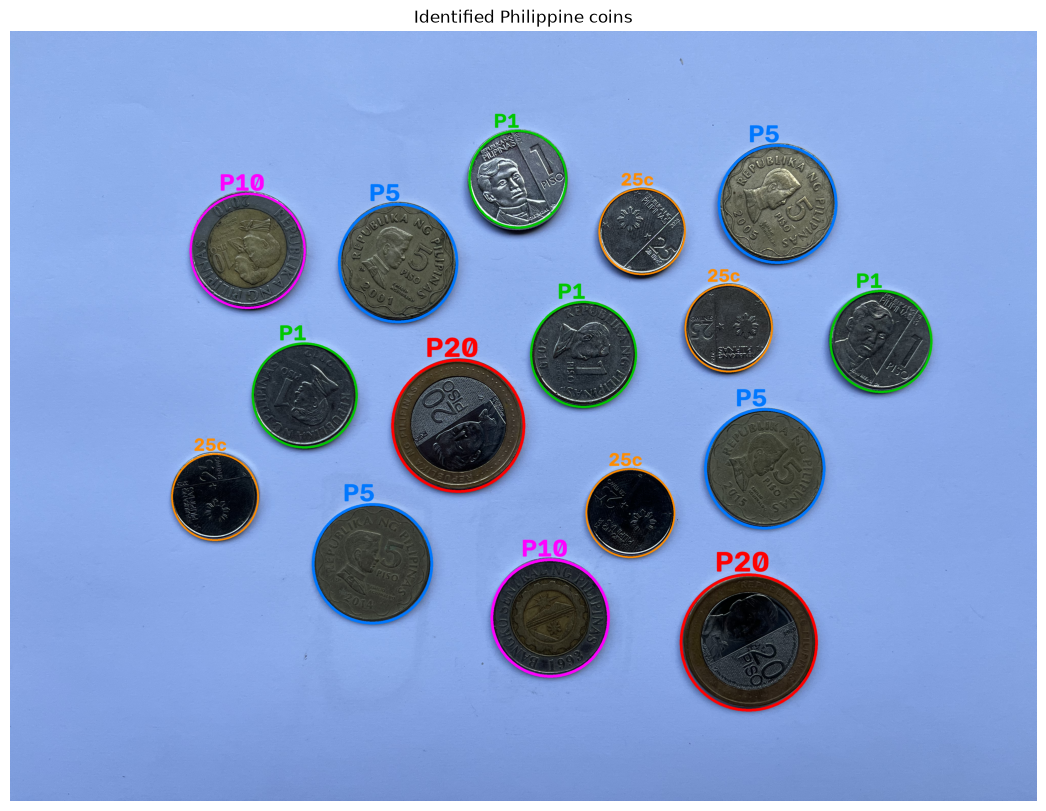

 #   Diameter   Ring b*  Center b*  Appearance                  Identified as
 1    25.9 mm      -5.4       12.8  silver ring, gold center    10 pesos
 2    26.7 mm       5.9        7.3  gold / brass                5 pesos
 3    22.0 mm      -8.5       -7.9  silver                      1 peso
 4    19.5 mm      -5.9       -6.1  silver                      25 centavos
 5    26.7 mm       6.9        7.9  gold / brass                5 pesos
 6    23.7 mm      -6.2       -6.2  silver                      1 peso
 7    30.0 mm      10.8       -6.2  gold ring, silver center    20 pesos
 8    23.9 mm      -4.5       -5.5  silver                      1 peso
 9    19.7 mm      -2.5       -2.6  silver                      25 centavos
10    23.0 mm      -4.6       -4.6  silver                      1 peso
11    19.6 mm      -6.2       -4.1  silver                      25 centavos
12    27.1 mm       3.8        3.9  gold / brass                5 pesos
13    20.1 mm      -4.7       -3.2  silver      

In [8]:
# --- draw ---
out = rgb.copy()
for c in coins:
    name, value, mm, color, short = SPECS[c["kind"]]
    R = int(c["d_px"] / 2)
    cv2.circle(out, (c["cx"], c["cy"]), R, color, max(3, R // 25))
    cv2.putText(out, short, (c["cx"] - R // 2, max(c["cy"] - R - 12, 30)),
                cv2.FONT_HERSHEY_SIMPLEX, max(0.9, R / 70), color, 3)

plt.figure(figsize=(14, 10))
plt.imshow(out); plt.axis("off"); plt.title("Identified Philippine coins")
plt.show()

# --- per-coin table ---
print(f"{'#':>2}  {'Diameter':>9}  {'Ring b*':>8}  {'Center b*':>9}  {'Appearance':<26}  Identified as")
for i, c in enumerate(coins, start=1):
    print(f"{i:>2}  {c['d_mm']:6.1f} mm  {c['b_ring']:8.1f}  {c['b_center']:9.1f}  "
          f"{c['look']:<26}  {SPECS[c['kind']][0]}")

# --- summary ---
counts = Counter(c["kind"] for c in coins)
total = 0
print("\n==== SUMMARY ====")
for key in ["25c", "1", "5", "10", "20"]:
    name, value = SPECS[key][0], SPECS[key][1]
    n = counts.get(key, 0)
    total += n * value
    print(f"{name:12s}: {n} coin(s)  = PHP {n * value:.2f}")
print("-----------------")
print(f"Total coins : {len(coins)}")
print(f"Total value : PHP {total:.2f}")